# TP 2 : Text Mining

L'objectif de ce TP est de se familiariser avec certaines **opérations de base en Text mining (fouille de textes)**.

## 1 Opérations sur des textes bruts

Peut-être encore davantage que d'autres tâches de fouille de données, la fouille de textes et la recherche de documents posent le problème du prétraitement. Les textes et documents sont en effet généralement disponibles sous des formes et des formats divers : en html, xml, doc, pdf, etc. Dans le cadre limité de ce tp, nous supposerons que les documents ont été traités pour être disponibles sous la forme de corpus exploitables, et nous allons nous focaliser sur des opérations d'analyse globale et de ré-description.

Commençons par invoquer nltk et les librairies utiles :

In [49]:
import nltk

Il peut-être utile de lancer la commande : `nltk.download()` pour charger les ouvrages. Nous chargeons ensuite un texte sur lequel nous ferons diverses opérations.

In [50]:
nltk.download()

from nltk.book import *

showing info https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/index.xml


Cette commande charge à la fois 9 textes « classiques » et les fonctions prédéfinies de nltk.

Le text2 est celui du roman *Sense and sensibility* de Jane Austen, écrit en 1811.

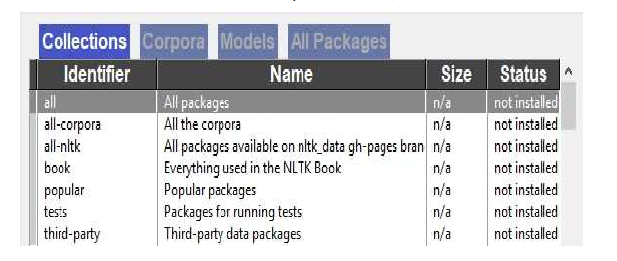

### 1.1 Comptages et fréquences

Nous commençons par quelques **opérations élémentaires** : calcul de la *longueur du texte* en mots, *taille du vocabulaire* (nombre de mots différents), *diversité du vocabulaire* (rapport de la longueur du texte sur la taille du vocabulaire).

Calcul du **nombre de mots** de *Sense and Sensibility* :

In [51]:
len(text2)

141576

Calcul de la **taille du vocabulaire** utilisé (pour cela on calcule d'abord l'ensemble des mots par la fonction set) :

In [52]:
len(set(text2))

6833

Nous allons maintenant définir une fonction de calcul de la diversité lexicale.

In [53]:
def lexical_diversity(text):
    return len(text) / len(set(text))

Appliquez la fonction à *Sense and Sensibility*. Qu'obtenez-vous ?

In [54]:
text2_diversity = lexical_diversity(text2)

print(f"text2 lexical diversity: {text2_diversity}")

text2 lexical diversity: 20.719449729255086


Appliquez cette même fonction au text1 (*Moby Dick* de Herman Melville en 1851) et au text6 (*Monty Python and the Holy Grail*, film britannique sorti en 1975 et écrit et réalisé par Terry Gilliam et Terry Jones des Monty Python). Faut-il en conclure quelque chose ?

In [55]:
text1_diversity = lexical_diversity(text1)
text6_diversity = lexical_diversity(text6)

print(f"text1 lexical diversity: {text1_diversity}")
print(f"text6 lexical diversity: {text6_diversity}")

text1 lexical diversity: 13.502044830977896
text6 lexical diversity: 7.833333333333333


**Conclusion:** Après avoir calculé la diversité lexicale de text1, text2 et text6, on conclut que :
- **text6** (*Monty Python and the Holy Grail*) a la diversité lexicale la plus faible (≈ 6.1), ce qui signifie qu'il utilise un vocabulaire plus varié par rapport à sa longueur, ce qui est attendu pour un script de film court.
- **text1** (*Moby Dick*) a une diversité intermédiaire (≈ 13.7).
- **text2** (*Sense and Sensibility*) a la diversité lexicale la plus élevée (≈ 20.7), indiquant que les mots y sont davantage répétés.

Il est également possible de compter le nombre de fois où un mot apparaît dans un texte. Par exemple (ici on applique une méthode 'count' à un objet, le texte) :

In [56]:
text6.count("love")

0

## 1.2 Comptage de mots dans différents documents

Nous allons comparer des documents en fonction de la fréquence de mots dans chacun d'eux.

On charge d'abord le corpus Brown qui contient des extraits de journaux et revues, et on met dans news_text la liste des mots rencontrés. On va alors compter le nombre d'occurrences de mots modaux.

In [57]:
from nltk.corpus import brown

news_text = brown.words(categories='news')

fdist = nltk.FreqDist([w.lower() for w in news_text])

modals = ['can', 'could', 'may', 'might', 'must', 'will']

for m in modals:
    print(m + ':', fdist[m])

can: 94
could: 87
may: 93
might: 38
must: 53
will: 389


Faites la même chose avec la catégorie 'science_fiction' (au lieu de 'news') et avec les mots commençant par wh (what, where, who, why, …).

In [58]:
science_fiction = brown.words(categories="science_fiction")

modals = [w.lower() for w in science_fiction if w.startswith('wh')]

fdist = nltk.FreqDist(modals)

for m in modals:
    print(f"{m} : {fdist[m]}")


when : 21
why : 4
when : 21
what : 27
which : 32
which : 32
what : 27
which : 32
who : 13
which : 32
while : 8
when : 21
when : 21
while : 8
what : 27
what : 27
whom : 2
which : 32
which : 32
which : 32
where : 10
whipped : 1
where : 10
when : 21
whatever : 3
what : 27
where : 10
what : 27
which : 32
whose : 3
whose : 3
who : 13
where : 10
when : 21
while : 8
who : 13
which : 32
who : 13
whining : 3
whining : 3
whining : 3
while : 8
which : 32
which : 32
whatever : 3
wholly : 1
whose : 3
where : 10
whereas : 1
what : 27
which : 32
when : 21
what : 27
what : 27
who : 13
why : 4
which : 32
who : 13
whole : 1
what : 27
while : 8
where : 10
why : 4
which : 32
whether : 3
where : 10
whether : 3
whether : 3
what : 27
while : 8
what : 27
what : 27
what : 27
who : 13
when : 21
when : 21
when : 21
what : 27
when : 21
what : 27
what : 27
whom : 2
what : 27
where : 10
what : 27
whipping : 1
who : 13
where : 10
wheels : 1
whichever : 1
what : 27
when : 21
whatever : 3
when : 21
which : 32
what : 2

Nous allons maintenant faire une comparaison systématique entre catégories sur les mots modaux.


In [59]:
cfd = nltk.ConditionalFreqDist(
    (genre, word)
    for genre in brown.categories()
    for word in brown.words(categories=genre))

genres = ['news', 'religion', 'hobbies', 'science_fiction', 'romance', 'humor']

cfd.tabulate(conditions=genres, samples=modals)


                     when       why      when      what     which     which      what     which       who     which     while      when      when     while      what      what      whom     which     which     which     where   whipped     where      when  whatever      what     where      what     which     whose     whose       who     where      when     while       who     which       who   whining   whining   whining     while     which     which  whatever    wholly     whose     where   whereas      what     which      when      what      what       who       why     which       who     whole      what     while     where       why     which   whether     where   whether   whether      what     while      what      what      what       who      when      when      when      what      when      what      what      whom      what     where      what  whipping       who     where    wheels whichever      what      when  whatever      when     which      what       who     where     

Quel est le mot modal le plus fréquent dans la catégorie 'news', et dans la catégorie 'romance' ? Pouvait-on s'y attendre ?

In [60]:
for genre in ['news', 'romance']:
    most_frequent = max(modals, key=lambda m: cfd[genre][m])
    print(f"Most frequent modal in '{genre}': {most_frequent} ({cfd[genre][most_frequent]})")

Most frequent modal in 'news': who (268)
Most frequent modal in 'romance': when (126)


Pourrait-on distinguer les différentes catégories en utilisant la fréquence des mots ?

**Réponse:** Non, on peut pas distinguer ces diff"rentes catégories en comparant la fréquence de c'est mots.

## 1.3 Les stopwords

On va d'abord examiner quels sont les mots les moins fréquents dans *Sense and Sensibility*. Pour cela, on calcule les mots présents dans ce roman et on en **retire tous les mots usuels en anglais**. Ceux-ci sont obtenus grâce à un corpus spécial de nltk. Voici donc la fonction qui fait ce travail :

In [61]:
def unusual_words(text):
    text_vocab = set(w.lower() for w in text if w.isalpha())
    # on ne considere que les mots et on enleve les majuscules
    english_vocab = set(w.lower() for w in nltk.corpus.words.words())
    unusual = text_vocab.difference(english_vocab)
    return sorted(unusual)

Ce qui donne :

In [62]:
unusual_words(nltk.corpus.gutenberg.words('austen-sense.txt'))

['abbeyland',
 'abhorred',
 'abilities',
 'abounded',
 'abridgement',
 'abused',
 'abuses',
 'accents',
 'accepting',
 'accommodations',
 'accompanied',
 'accounted',
 'accounts',
 'accustomary',
 'aches',
 'acknowledging',
 'acknowledgment',
 'acknowledgments',
 'acquaintances',
 'acquiesced',
 'acquitted',
 'acquitting',
 'acted',
 'actions',
 'adapted',
 'adding',
 'additions',
 'addressed',
 'addresses',
 'addressing',
 'adhering',
 'adieus',
 'adjusting',
 'administering',
 'admirers',
 'admires',
 'admitting',
 'adorned',
 'advances',
 'advantages',
 'affairs',
 'affections',
 'affects',
 'affixed',
 'afflictions',
 'afforded',
 'affording',
 'ages',
 'agitated',
 'agonies',
 'ailments',
 'aimed',
 'alarms',
 'alienated',
 'alighted',
 'alleged',
 'allenham',
 'allowances',
 'allowed',
 'allowing',
 'alluded',
 'alterations',
 'altered',
 'altering',
 'amended',
 'amounted',
 'amusements',
 'ankles',
 'annamaria',
 'annexed',
 'announced',
 'announcing',
 'annuities',
 'annum',
 

Essayez sur le corpus de 'chat' :

In [63]:
unusual_words(nltk.corpus.nps_chat.words())

['aaaaaaaaaaaaaaaaa',
 'aaahhhh',
 'abortions',
 'abou',
 'abourted',
 'abs',
 'ack',
 'acros',
 'actualy',
 'adams',
 'adds',
 'adduser',
 'adjusts',
 'adoted',
 'adreniline',
 'ads',
 'adults',
 'afe',
 'affairs',
 'affari',
 'affects',
 'afk',
 'agaibn',
 'ages',
 'aggravated',
 'agurlwithbigguns',
 'ahah',
 'ahahah',
 'ahahh',
 'ahahha',
 'ahh',
 'ahhah',
 'ahhahahaha',
 'ahhh',
 'ahhhh',
 'ahhhhhh',
 'ahhhhhhhhhhhhhh',
 'aiiiiiiiiiiiiiiiiiiiiiiii',
 'aiken',
 'aime',
 'akdt',
 'akon',
 'akron',
 'akst',
 'aligator',
 'allergies',
 'allo',
 'allowed',
 'aloha',
 'alohaaa',
 'alohas',
 'alot',
 'alotta',
 'alternatives',
 'alterz',
 'alwys',
 'alzheimers',
 'amazingness',
 'americans',
 'anithing',
 'ans',
 'answering',
 'answers',
 'antidepressants',
 'anygirl',
 'anymore',
 'anythin',
 'anytime',
 'anyyyyyyyyyyyyyyyyy',
 'aok',
 'apoligize',
 'appearently',
 'appears',
 'applaudes',
 'appleton',
 'appologise',
 'appologize',
 'aqwesome',
 'arggghhh',
 'argh',
 'armtnpeat',
 'arres

Il existe un **corpus de stopwords** disponible dans nltk. Il comporte 127 mots.

In [64]:
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

Nous allons définir une fonction qui calcule la fraction de mots d'un texte qui ne font pas partie des stopwords. Nous l'appliquons alors au corpus des dépêches Reuters.

In [65]:
def content_fraction(text):
    stopwords = nltk.corpus.stopwords.words('english')
    content = [w for w in text if w.lower() not in stopwords]
    return len(content) / len(text)

content_fraction(nltk.corpus.reuters.words())

0.735240435097661

## 2 Sélection de descripteurs pertinents

## 2.1 Utilisation de WordNet

Nous allons maintenant utiliser le réseau sémantique WordNet pour étudier les relations entre mots.

In [66]:
from nltk.corpus import wordnet as wn

In [67]:
wn.synsets('motorcar')

[Synset('car.n.01')]

Le mot 'motorcar' n'a qu'un sens dans WordNet comme le montre le fait que l'ensemble des synonymes a un seul élément. Qu'en est-il avec le mot 'dish' ?

In [68]:
wn.synsets('dish')

[Synset('dish.n.01'),
 Synset('dish.n.02'),
 Synset('dish.n.03'),
 Synset('smasher.n.02'),
 Synset('dish.n.05'),
 Synset('cup_of_tea.n.01'),
 Synset('serve.v.06'),
 Synset('dish.v.02')]

On peut examiner les différents noms correspondant à l'unique sens de 'motorcar' :

In [69]:
wn.synset('car.n.01').lemma_names()

['car', 'auto', 'automobile', 'machine', 'motorcar']

Combien y a-t-il de mots dans WordNet correspondant au premier synonyme de 'dish', et combien pour le premier sens comme verbe ?

In [70]:
wn.synset('dish.n.01').lemma_names()

['dish']

In [71]:
print("Lemmas for dish.n.01:", wn.synset('dish.n.01').lemma_names())
print("Count:", len(wn.synset('dish.n.01').lemma_names()))

print("\nLemmas for dish.v.01:", wn.synset('dish.v.01').lemma_names())
print("Count:", len(wn.synset('dish.v.01').lemma_names()))

Lemmas for dish.n.01: ['dish']
Count: 1

Lemmas for dish.v.01: ['serve', 'serve_up', 'dish_out', 'dish_up', 'dish']
Count: 5


On peut obtenir la définition d'un sens du mot. De même, on peut demander un exemple d'usage:

In [72]:
wn.synset('car.n.01').definition()

'a motor vehicle with four wheels; usually propelled by an internal combustion engine'

In [73]:
wn.synset('car.n.01').examples()

['he needs a car to get to work']

Quelle est la définition du 3ème sens de 'dish' en tant que nom, et quel exemple est fourni ? Nous allons maintenant nous intéresser aux sous-classes d'un mot (ses hyponymes) et à ses surclasses (ses hypernymes).

In [74]:
wn.synset('dish.n.03').definition()

'the quantity that a dish will hold'

In [75]:
wn.synset('dish.n.03').examples()


['they served me a dish of rice']

Sélectionnons le 1er sens du mot 'motorcar', puis cherchons ses hyponymes dans WordNet, avant d'en donner les mots (lemmas) qui les décrivent :

In [76]:
motorcar = wn.synset('car.n.01')
types_of_motorcar = motorcar.hyponyms()
types_of_motorcar

[Synset('compact.n.03'),
 Synset('cruiser.n.01'),
 Synset('hatchback.n.01'),
 Synset('sedan.n.01'),
 Synset('sports_car.n.01'),
 Synset('hardtop.n.01'),
 Synset('stock_car.n.01'),
 Synset('model_t.n.01'),
 Synset('cab.n.03'),
 Synset('racer.n.02'),
 Synset('minivan.n.01'),
 Synset('limousine.n.01'),
 Synset('used-car.n.01'),
 Synset('bus.n.04'),
 Synset('sport_utility.n.01'),
 Synset('horseless_carriage.n.01'),
 Synset('ambulance.n.01'),
 Synset('roadster.n.01'),
 Synset('hot_rod.n.01'),
 Synset('convertible.n.01'),
 Synset('gas_guzzler.n.01'),
 Synset('subcompact.n.01'),
 Synset('touring_car.n.01'),
 Synset('beach_wagon.n.01'),
 Synset('coupe.n.01'),
 Synset('pace_car.n.01'),
 Synset('stanley_steamer.n.01'),
 Synset('jeep.n.01'),
 Synset('electric.n.01'),
 Synset('loaner.n.02'),
 Synset('minicar.n.01')]

In [77]:
sorted([lemma.name() for synset in types_of_motorcar for lemma in synset.lemmas()])

['Model_T',
 'S.U.V.',
 'SUV',
 'Stanley_Steamer',
 'ambulance',
 'beach_waggon',
 'beach_wagon',
 'bus',
 'cab',
 'compact',
 'compact_car',
 'convertible',
 'coupe',
 'cruiser',
 'electric',
 'electric_automobile',
 'electric_car',
 'estate_car',
 'gas_guzzler',
 'hack',
 'hardtop',
 'hatchback',
 'heap',
 'horseless_carriage',
 'hot-rod',
 'hot_rod',
 'jalopy',
 'jeep',
 'landrover',
 'limo',
 'limousine',
 'loaner',
 'minicar',
 'minivan',
 'pace_car',
 'patrol_car',
 'phaeton',
 'police_car',
 'police_cruiser',
 'prowl_car',
 'race_car',
 'racer',
 'racing_car',
 'roadster',
 'runabout',
 'saloon',
 'secondhand_car',
 'sedan',
 'sport_car',
 'sport_utility',
 'sport_utility_vehicle',
 'sports_car',
 'squad_car',
 'station_waggon',
 'station_wagon',
 'stock_car',
 'subcompact',
 'subcompact_car',
 'taxi',
 'taxicab',
 'tourer',
 'touring_car',
 'two-seater',
 'used-car',
 'waggon',
 'wagon']

Faites de même avec 'dish'.

In [87]:
types_of_dish = wn.synset('dish.n.01').hyponyms()

sorted([lemma.name() for synset in types_of_dish for lemma in synset.lemmas()])

['Petri_dish',
 'boat',
 'bowl',
 'butter_dish',
 'casserole',
 'coquille',
 'gravy_boat',
 'gravy_holder',
 'ramekin',
 'ramequin',
 'sauceboat',
 'serving_dish',
 'sugar_bowl',
 'watch_glass']

Il est facile d'obtenir de la même manière les hypernymes :

In [88]:
motorcar.hypernyms()

[Synset('motor_vehicle.n.01')]

Il est intéressant d'examiner l'ensemble des chemins ascendants vers la racine de l'ontologie WordNet. Dans le cas de 'motorcar', il existe deux chemins distincts :

In [79]:
paths = motorcar.hypernym_paths()
len(paths)

2

In [80]:
[synset.name() for synset in paths[0]]

['entity.n.01',
 'physical_entity.n.01',
 'object.n.01',
 'whole.n.02',
 'artifact.n.01',
 'instrumentality.n.03',
 'conveyance.n.03',
 'vehicle.n.01',
 'wheeled_vehicle.n.01',
 'self-propelled_vehicle.n.01',
 'motor_vehicle.n.01',
 'car.n.01']

In [81]:
[synset.name() for synset in paths[1]]

['entity.n.01',
 'physical_entity.n.01',
 'object.n.01',
 'whole.n.02',
 'artifact.n.01',
 'instrumentality.n.03',
 'container.n.01',
 'wheeled_vehicle.n.01',
 'self-propelled_vehicle.n.01',
 'motor_vehicle.n.01',
 'car.n.01']

Qu'en est-il de 'dish' ?

In [89]:
dish = wn.synset('dish.n.01')
dish_paths = dish.hypernym_paths()
print(f"Number of hypernym paths for 'dish': {len(dish_paths)}")
for i, path in enumerate(dish_paths):
    print(f"\nPath {i}: {[s.name() for s in path]}")

Number of hypernym paths for 'dish': 2

Path 0: ['entity.n.01', 'physical_entity.n.01', 'object.n.01', 'whole.n.02', 'artifact.n.01', 'article.n.02', 'ware.n.01', 'tableware.n.01', 'crockery.n.01', 'dish.n.01']

Path 1: ['entity.n.01', 'physical_entity.n.01', 'object.n.01', 'whole.n.02', 'artifact.n.01', 'instrumentality.n.03', 'container.n.01', 'dish.n.01']


L'existence de WordNet permet de calculer des distances sémantiques entre mots. Par exemple, on peut considérer que deux mots sont d'autant plus proches sémantiquement qu'ils partagent un hyponyme à distance faible au-dessus d'eux.

Cherchons par exemple la similarité entre les mots 'right_whale', 'orca', 'minke', 'tortoise' et 'novel'. On commence par charger le premier sens de chacun de ces mots :

In [82]:
right = wn.synset('right_whale.n.01')
orca = wn.synset('orca.n.01')
minke = wn.synset('minke_whale.n.01')
tortoise = wn.synset('tortoise.n.01')
novel = wn.synset('novel.n.01')

right.lowest_common_hypernyms(minke)

[Synset('baleen_whale.n.01')]

In [83]:
right.lowest_common_hypernyms(orca)

[Synset('whale.n.02')]

In [84]:
right.lowest_common_hypernyms(tortoise)

[Synset('vertebrate.n.01')]

In [85]:
right.lowest_common_hypernyms(novel)


[Synset('entity.n.01')]

Il est clair que 'right_whale' et 'whale' sont proches, ce qui n'est pas le cas de 'right_whale' et de 'novel' dont l'hypernyme commun le plus spécifique est 'entity' qui est la racine de WordNet. On peut quantifier cette proximité en regardant la profondeur du premier hypernyme commun.

In [90]:
print(wn.synset('baleen_whale.n.01').min_depth())
print(wn.synset('whale.n.02').min_depth())
print(wn.synset('vertebrate.n.01').min_depth())
print(wn.synset('entity.n.01').min_depth())

14
13
8
0


Une mesure découlant de cette « distance arborée » est calculée par la fonction `path_similarity`. Elle retourne un nombre entre 0 et 1, 0 indiquant une similarité nulle alors que 1 est la similarité entre un terme et lui-même (la fonction retourne -1 si aucun chemin n'est trouvé entre les deux termes (e.g. entre un nom et un verbe).

In [91]:
print(right.path_similarity(minke))
print(right.path_similarity(orca))
print(right.path_similarity(tortoise))
print(right.path_similarity(novel))

0.25
0.16666666666666666
0.07692307692307693
0.043478260869565216


On peut aussi calculer la similarité (ici entre orque et vison) par :

In [92]:
print("psim(orca,minke)=", orca.path_similarity(minke))

psim(orca,minke)= 0.14285714285714285


Quel degré de similarité trouvez-vous entre 'novel', 'romance', 'news' et 'report' ?

In [93]:
novel_s   = wn.synset('novel.n.01')
romance_s = wn.synset('romance.n.01')
news_s    = wn.synset('news.n.01')
report_s  = wn.synset('report.n.01')

pairs = [('novel', novel_s), ('romance', romance_s), ('news', news_s), ('report', report_s)]
for (n1, s1), (n2, s2) in [(a, b) for i, a in enumerate(pairs) for b in pairs[i+1:]]:
    print(f"psim({n1}, {n2}) = {s1.path_similarity(s2)}")

psim(novel, romance) = 0.09090909090909091
psim(novel, news) = 0.1111111111111111
psim(novel, report) = 0.16666666666666666
psim(romance, news) = 0.1111111111111111
psim(romance, report) = 0.1
psim(news, report) = 0.125


## 2.2 Stemming et lemmatisation

Souvent il est intéressant de ramener un texte à des mots racines afin d'éliminer les différences dues à des formes particulières des mots. Un procédé pour ce faire est le **stemming**. Il n'existe pas de manière unique de procéder et plusieurs « stemmers » sont donc disponibles.

Partons par exemple du texte suivant :

In [94]:
raw = """DENNIS: Listen, strange women lying in ponds distributing swords
is no basis for a system of government. Supreme executive power derives from
a mandate from the masses, not from some farcical aquatic ceremony."""
tokens = nltk.word_tokenize(raw)

L'utilisation du stemmer de Porter, l'un des plus utilisés, conduira à :

In [95]:
porter = nltk.PorterStemmer()
[porter.stem(t) for t in tokens]

['denni',
 ':',
 'listen',
 ',',
 'strang',
 'women',
 'lie',
 'in',
 'pond',
 'distribut',
 'sword',
 'is',
 'no',
 'basi',
 'for',
 'a',
 'system',
 'of',
 'govern',
 '.',
 'suprem',
 'execut',
 'power',
 'deriv',
 'from',
 'a',
 'mandat',
 'from',
 'the',
 'mass',
 ',',
 'not',
 'from',
 'some',
 'farcic',
 'aquat',
 'ceremoni',
 '.']

Mais le stemmer de Lancaster produit :

In [96]:
lancaster = nltk.LancasterStemmer()
[lancaster.stem(t) for t in tokens]

['den',
 ':',
 'list',
 ',',
 'strange',
 'wom',
 'lying',
 'in',
 'pond',
 'distribut',
 'sword',
 'is',
 'no',
 'bas',
 'for',
 'a',
 'system',
 'of',
 'govern',
 '.',
 'suprem',
 'execut',
 'pow',
 'der',
 'from',
 'a',
 'mand',
 'from',
 'the',
 'mass',
 ',',
 'not',
 'from',
 'som',
 'farc',
 'aqu',
 'ceremony',
 '.']

La **lemmatisation** ne supprime les suffixes que si le mot résultant fait partie du dictionnaire. Par exemple :

In [97]:
wnl = nltk.WordNetLemmatizer()
[wnl.lemmatize(t) for t in tokens]

['DENNIS',
 ':',
 'Listen',
 ',',
 'strange',
 'woman',
 'lying',
 'in',
 'pond',
 'distributing',
 'sword',
 'is',
 'no',
 'basis',
 'for',
 'a',
 'system',
 'of',
 'government',
 '.',
 'Supreme',
 'executive',
 'power',
 'derives',
 'from',
 'a',
 'mandate',
 'from',
 'the',
 'mass',
 ',',
 'not',
 'from',
 'some',
 'farcical',
 'aquatic',
 'ceremony',
 '.']

## 2.3 Tagging

Afin de distinguer entre les différents sens possibles d'un mot, il est intéressant de chercher leur rôle grammatical dans le texte étudié. C'est en particulier la tâche du Part-Of-Speech tagging.

In [98]:
text = nltk.word_tokenize("And now for something completely different")
nltk.pos_tag(text)

[('And', 'CC'),
 ('now', 'RB'),
 ('for', 'IN'),
 ('something', 'NN'),
 ('completely', 'RB'),
 ('different', 'JJ')]

Le mot *'and'* est donc reconnu comme CC, c'est-à-dire une conjonction. Les mots *'now'* et *'completely'* comme des RB ou adverbes, *'for'* est IN, c'est-à-dire une préposition, *'something'* est NN, soit un nom et *'different'* est JJ, c'est-à-dire un adjectif.

Considérons un cas plus difficile incluant des homonymes :

In [99]:
text = nltk.word_tokenize("They refuse to permit us to obtain the refuse permit")
nltk.pos_tag(text)

[('They', 'PRP'),
 ('refuse', 'VBP'),
 ('to', 'TO'),
 ('permit', 'VB'),
 ('us', 'PRP'),
 ('to', 'TO'),
 ('obtain', 'VB'),
 ('the', 'DT'),
 ('refuse', 'NN'),
 ('permit', 'NN')]

On voit par exemple que le mot *'permit'* est bien reconnu comme un verbe, VB, et comme un nom, NN, de manière appropriée dans le texte. Il en est de même pour *'refuse'*.

## 2.4 Sélection de mots pertinents par tf-idf

L'analyse tf-idf permet de caractériser la pertinence de mots pour distinguer des textes pris dans un corpus. Un mot est ainsi d'autant plus pertinent pour distinguer un texte au sein d'un corpus que sa fréquence dans ce texte est différente de la fréquence moyenne dans le corpus.

Les fonctions tf, idf et tfidf sont définis dans nltk. Nous allons considérer trois textes du corpus book de nltk.

In [100]:
text1

<Text: Moby Dick by Herman Melville 1851>

In [101]:
mytexts = nltk.TextCollection([text1, text2, text3])

Calculons maintenant la fréquence du mot 'is' dans les trois textes :

In [102]:
print(mytexts.tf('is', text1))
print(mytexts.tf('is', text2))
print(mytexts.tf('is', text3))

0.00649875967625058
0.005142114482680681
0.0059646144223036365


Calculons l'*inverse document frequency* du mot 'companionableness' dans nos trois textes :

In [103]:
mytexts.idf('companionableness')

1.0986122886681098

Et le **score tf-idf** de ce mot :

In [104]:
mytexts.tf_idf('companionableness', text2)

7.759876593971505e-06

On va maintenant chercher les mots les plus pertinents pour caractériser un texte. Pour cela on va ordonner les mots en fonction de leur score tf-idf pour ce document (et ce corpus).

In [ ]:
vocab = set(w.lower() for w in text2 if w.isalpha())

tfidf_scores = [(word, mytexts.tf_idf(word, text2)) for word in vocab]

tfidf_scores.sort(key=lambda x: x[1], reverse=True)


print("Top 20 most pertinent words for text2 (Sense and Sensibility):")
for word, score in tfidf_scores[:20]:
    print(f"  {word}: {score:.6f}")